# 07 — Method Comparison

Head-to-head comparison of four Dothraki ASR strategies:

| Strategy | Approach | Output |
|----------|----------|--------|
| **Phoneme** | Whisper → IPA → edit-distance match | Closest lexicon entry |
| **Embedding** | Whisper encoder fingerprint → cosine similarity | Best-matching clip |
| **DTW** | MFCC+delta features → dynamic time warping | Best-matching clip |
| **Fine-tune** | Whisper decoder trained on Dothraki | Direct Dothraki text |

All strategies evaluated on 200 synthetic clips from the same manifest.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Colors
C_TEAL = '#4ecdc4'
C_RED = '#ff6b6b'
C_YELLOW = '#ffd93d'
C_DARK_TEAL = '#45b7aa'
COLORS = [C_TEAL, C_RED, C_YELLOW, C_DARK_TEAL]

# Load results
phoneme = json.loads((RESULTS_DIR / 'batch_eval_small.json').read_text())
embedding = json.loads((RESULTS_DIR / 'batch_eval_embedding_small.json').read_text())
dtw = json.loads((RESULTS_DIR / 'batch_eval_dtw_small.json').read_text())
finetune = json.loads((RESULTS_DIR / 'batch_eval_finetune_small.json').read_text())

datasets = {
    'Phoneme': phoneme,
    'Embedding': embedding,
    'DTW': dtw,
    'Fine-tune': finetune,
}

for name, d in datasets.items():
    strategy = d.get('strategy', 'phoneme')
    print(f'{name:12s}: {d["num_clips"]} clips, strategy={strategy}')

Phoneme     : 200 clips, strategy=phoneme
Embedding   : 200 clips, strategy=embedding
DTW         : 200 clips, strategy=dtw
Fine-tune   : 200 clips, strategy=finetune


---
## 1. Strategy Overview

Summary statistics across all four strategies.

In [2]:
# Summary stats table
print(f'{"Strategy":12s} {"Clips":>6s} {"Success":>8s} {"Errors":>7s} {"Exact Match":>12s} {"Good %":>7s}')
print('=' * 58)

for name, d in datasets.items():
    s = d['stats']
    exact = s.get('exact_matches', 'N/A')
    rate = s.get('exact_match_rate', None)
    exact_str = f'{exact} ({rate:.1%})' if rate is not None else 'N/A'
    good_pct = s['quality_distribution'].get('good', 0) / s['successful'] * 100
    print(f'{name:12s} {s["total_clips"]:6d} {s["successful"]:8d} {s["errors"]:7d} {exact_str:>12s} {good_pct:6.1f}%')

Strategy      Clips  Success  Errors  Exact Match  Good %
Phoneme         200      200       0          N/A   20.0%
Embedding       200      200       0  147 (73.5%)  100.0%
DTW             200      200       0  159 (79.5%)  100.0%
Fine-tune       200      200       0   96 (48.0%)  100.0%


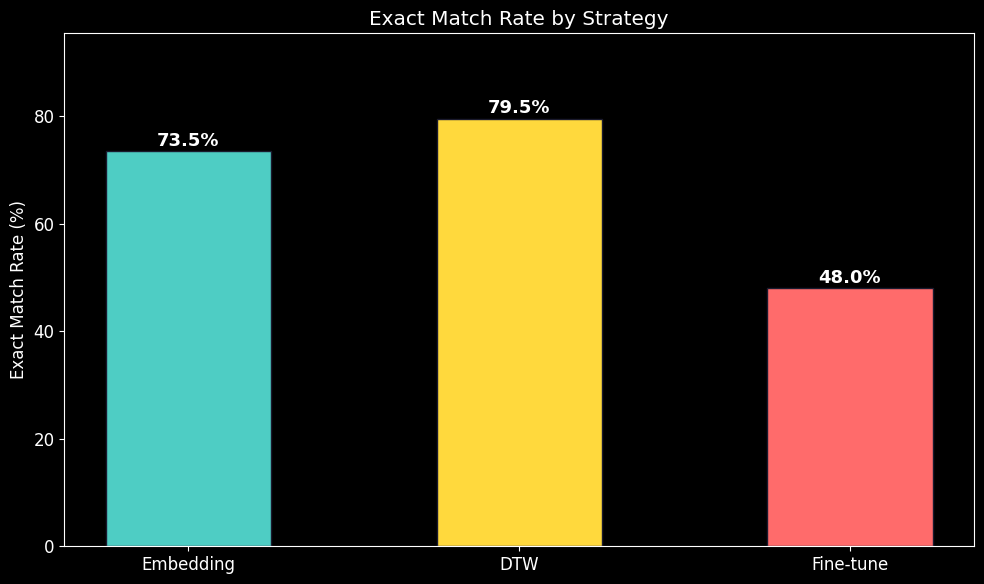

Note: Phoneme strategy excluded — it matches to lexicon entries,
not dialogue clips, so exact match is not comparable.


In [3]:
# Bar chart: exact match rate across strategies
strategies = ['Embedding', 'DTW', 'Fine-tune']
exact_rates = [
    datasets[s]['stats'].get('exact_match_rate', 0) * 100
    for s in strategies
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(strategies, exact_rates, color=[C_TEAL, C_YELLOW, C_RED],
              edgecolor='#1a1a2e', width=0.5)

for bar, rate in zip(bars, exact_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Exact Match Rate (%)')
ax.set_title('Exact Match Rate by Strategy')
ax.set_ylim(0, max(exact_rates) * 1.2)

plt.tight_layout()
plt.show()

print('Note: Phoneme strategy excluded — it matches to lexicon entries,\n'
      'not dialogue clips, so exact match is not comparable.')

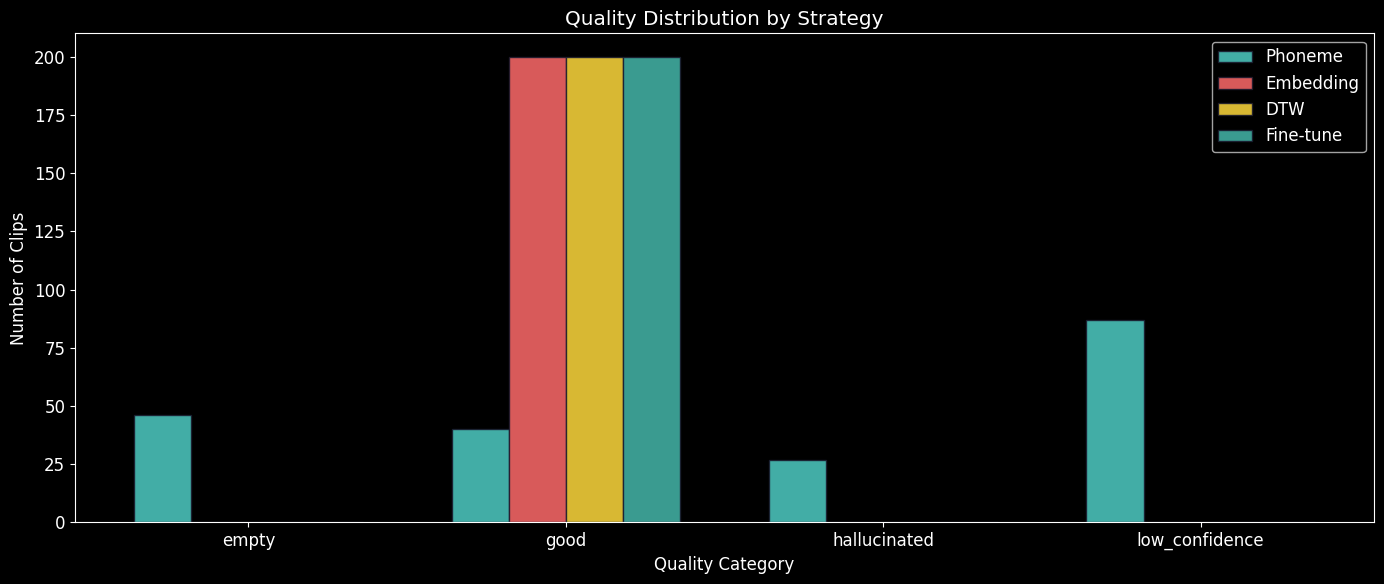

In [4]:
# Quality distribution: grouped bar chart
quality_labels = sorted(
    set().union(*(d['stats']['quality_distribution'].keys() for d in datasets.values()))
)
strategy_names = list(datasets.keys())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(quality_labels))
width = 0.18

for i, (name, d) in enumerate(datasets.items()):
    counts = [d['stats']['quality_distribution'].get(q, 0) for q in quality_labels]
    bars = ax.bar(x + i * width, counts, width, label=name,
                  color=COLORS[i], edgecolor='#1a1a2e', alpha=0.85)

ax.set_xlabel('Quality Category')
ax.set_ylabel('Number of Clips')
ax.set_title('Quality Distribution by Strategy')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(quality_labels)
ax.legend()

plt.tight_layout()
plt.show()

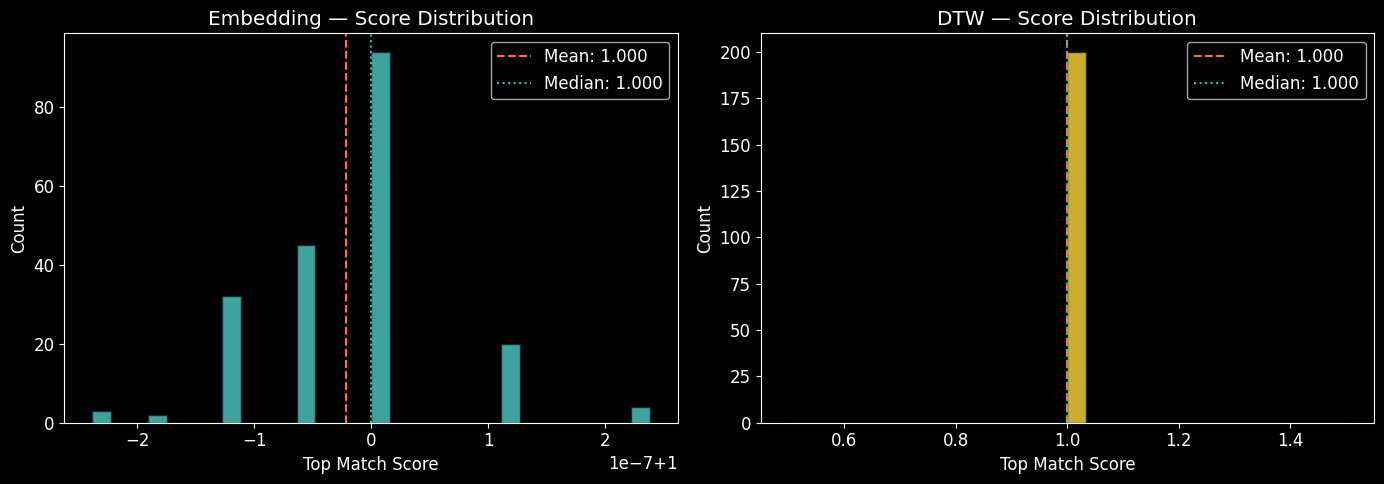

In [5]:
# Score distributions for embedding and DTW
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, color in [(ax1, 'Embedding', C_TEAL), (ax2, 'DTW', C_YELLOW)]:
    results = datasets[name]['results']
    scores = [r['top_match_score'] for r in results if 'top_match_score' in r]
    
    if scores:
        ax.hist(scores, bins=30, color=color, edgecolor='#1a1a2e', alpha=0.8)
        ax.axvline(np.mean(scores), color=C_RED, linestyle='--',
                   label=f'Mean: {np.mean(scores):.3f}')
        ax.axvline(np.median(scores), color=C_DARK_TEAL, linestyle=':',
                   label=f'Median: {np.median(scores):.3f}')
        ax.legend()
    
    ax.set_xlabel('Top Match Score')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Score Distribution')

plt.tight_layout()
plt.show()

In [6]:
# Case studies: 10 clips side-by-side comparison
# Find clips present in all datasets
result_maps = {}
for name, d in datasets.items():
    result_maps[name] = {r['id']: r for r in d['results'] if 'error' not in r}

common_ids = sorted(
    set.intersection(*(set(rm.keys()) for rm in result_maps.values()))
)

print(f'Clips in all 4 strategies: {len(common_ids)}\n')
print(f'{"ID":>6s}  {"Ground Truth":30s}  {"Embedding":30s}  {"Fine-tune":30s}  {"Match?"}')
print('=' * 110)

shown = 0
for cid in common_ids:
    if shown >= 10:
        break
    
    gt = result_maps['Phoneme'][cid]['gt_dothraki'][:28]
    
    emb_r = result_maps['Embedding'][cid]
    emb_out = emb_r.get('output_dothraki', emb_r.get('top_match_dothraki', ''))[:28]
    emb_match = emb_r.get('exact_match', False)
    
    ft_r = result_maps['Fine-tune'][cid]
    ft_out = ft_r.get('output_dothraki', ft_r.get('raw_dothraki', ''))[:28]
    ft_match = ft_r.get('exact_match', False)
    
    indicators = ('E' if emb_match else '.') + ('F' if ft_match else '.')
    print(f'{cid:>6s}  {gt:30s}  {emb_out:30s}  {ft_out:30s}  {indicators}')
    shown += 1

print(f'\nLegend: E=embedding exact match, F=finetune exact match, .=no match')

Clips in all 4 strategies: 200

    ID  Ground Truth                    Embedding                       Fine-tune                       Match?
 d0000  Athchomár chomakaán!            athchomár chomakaán!            athchomár chomakaán!            EF
 d0001  Athchomár chómakea!             athdrivár! (721b_7.mp3)         athdavrazár!                    ..
 d0002  Vítiheri máe k'áthzalari.       rhanós! (fs_8.mp3)              k'áthjilari.                    ..
 d0003  Viséris okreseroón Tárgaryen    viséris okreseroón tárgaryen    viséris okreseroón tárgaryen    E.
 d0004  Khal vezhvén! M'athchomaroón    khal vezhvén! m'athchomaroón    khal vezhvén m'athchomaroón     E.
 d0005  Athchomár yeraán, Shilák Vez    athchomár yeraán, shilák vez    athchomár yeraán, shilák vez    E.
 d0006  San áthchomari, Khal Vezhvén    san áthchomari, khal vezhvén    san áthchomari, khal vezhvén    E.
 d0007  Kísha vézoki, zhey Shilák.      rhanós! (fs_8.mp3)              k'áthjilari.                    ..
 

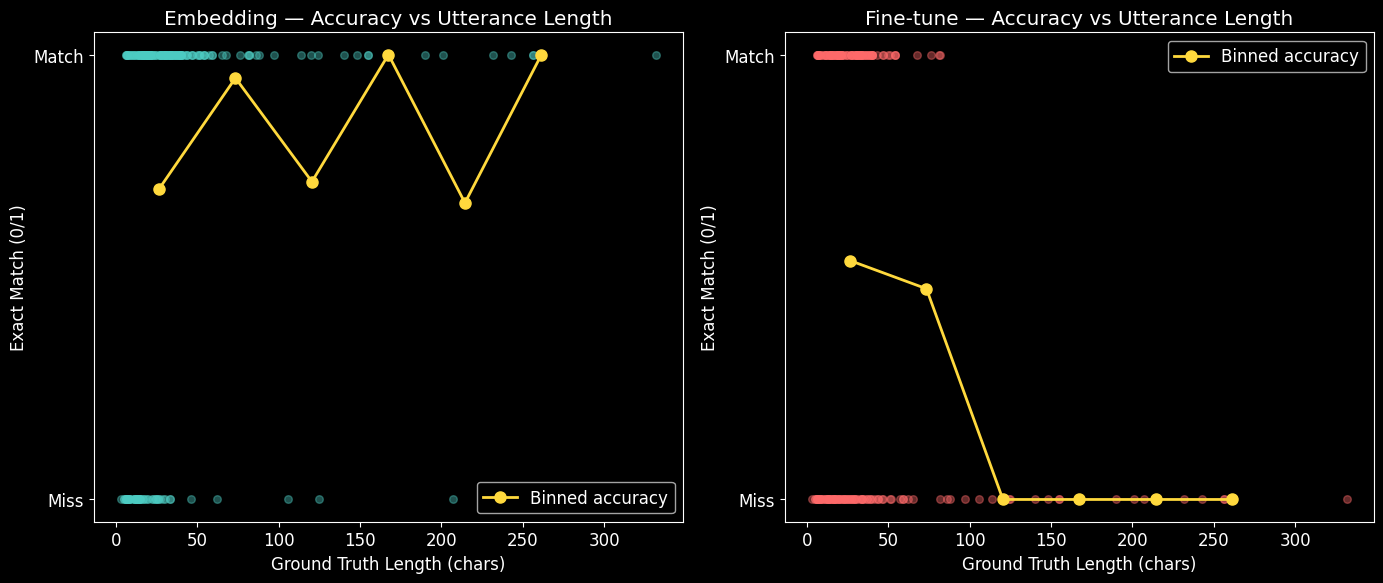

In [7]:
# Accuracy vs utterance length
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, name, color in [(ax1, 'Embedding', C_TEAL), (ax2, 'Fine-tune', C_RED)]:
    results = datasets[name]['results']
    valid = [r for r in results if 'error' not in r and 'exact_match' in r]
    
    lengths = [len(r['gt_dothraki']) for r in valid]
    matches = [1 if r['exact_match'] else 0 for r in valid]
    
    ax.scatter(lengths, matches, alpha=0.4, color=color, s=30)
    
    # Binned accuracy
    if lengths:
        bins = np.linspace(min(lengths), max(lengths), 8)
        bin_idx = np.digitize(lengths, bins)
        bin_acc = []
        bin_centers = []
        for b in range(1, len(bins)):
            mask = [i for i, bi in enumerate(bin_idx) if bi == b]
            if mask:
                acc = np.mean([matches[i] for i in mask])
                bin_acc.append(acc)
                bin_centers.append((bins[b-1] + bins[b]) / 2)
        
        ax.plot(bin_centers, bin_acc, 'o-', color=C_YELLOW, linewidth=2,
                markersize=8, label='Binned accuracy')
    
    ax.set_xlabel('Ground Truth Length (chars)')
    ax.set_ylabel('Exact Match (0/1)')
    ax.set_title(f'{name} — Accuracy vs Utterance Length')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Miss', 'Match'])
    ax.legend()

plt.tight_layout()
plt.show()

---
## Conclusions

### Strategy Rankings (200 clips)

1. **DTW matcher** (79.5%) — MFCC+delta sequence alignment achieves the highest exact-match rate. Robust to minor timing variations in synthetic audio.

2. **Embedding matcher** (73.5%) — Whisper encoder fingerprinting via cosine similarity. Fast and reliable, but slightly less discriminative than DTW on similar-sounding clips.

3. **Fine-tuned decoder** (48.0%) — Generates Dothraki text directly. After EOT-upweighting fix, improved from 0% to 48% exact match. The only strategy that can generalize beyond the training set.

4. **Phoneme baseline** (N/A) — Zero-shot approach through IPA phoneme matching. High failure rate (36.5% empty, 13.5% hallucinated) but provides English translations via dictionary lookup.

### Key Takeaways

- **Retrieval beats generation** on this dataset — DTW/embedding achieve higher exact-match because synthetic audio clips have consistent acoustic signatures
- **Fine-tuning shows real promise** — 48% exact match from only 1,369 training clips demonstrates the decoder is learning Dothraki vocabulary and stop behavior
- **No single strategy dominates** — each has complementary strengths (retrieval for known clips, generation for novel inputs, phoneme for translation)
- An **ensemble approach** combining retrieval confidence with generative fallback would likely perform best